In [ ]:
# Instalando pacotes necessários para análise
install.packages("fitdistrplus")
install.packages("knitr")
install.packages("lmtest")
install.packages("FNN")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘zoo’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



A

In [16]:
# Carregando bibliotecas
library(tidyr)
library(dplyr)
library(fitdistrplus)
library(ggplot2)
library(knitr)
library(lmtest)
library(FNN)
library(class)


In [ ]:
# Carregando a base de dados
df <- read.csv("criminalidade_baixada_santista.csv")

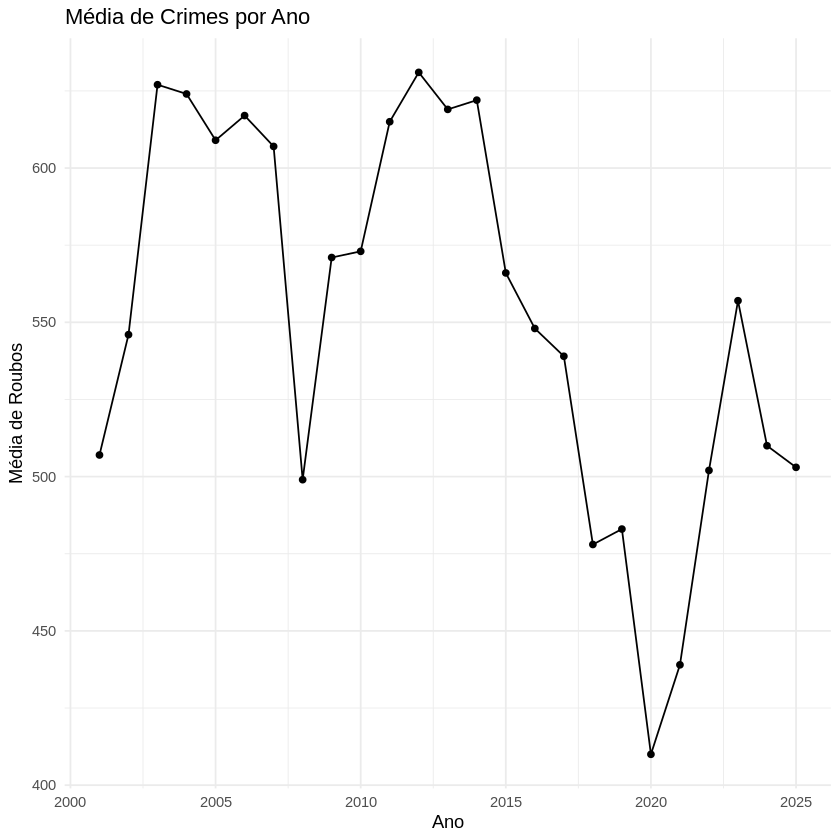

In [ ]:
# Calculando a média anual e plotando gráfico de linha
df %>%
  group_by(ANO) %>%
  summarise(MEDIA = round(mean(TOTAL_CRIME, na.rm = TRUE))) %>%
  ggplot(aes(x = ANO, y = MEDIA)) +
  geom_line() +
  geom_point() +
  labs(
    title = "Média de Crimes por Ano",
    x = "Ano",
    y = "Média de Roubos"
  ) +
  theme_minimal()

In [ ]:
# Calculando a mediana anual de crimes
df %>% group_by(ANO) %>% summarise(MEDIANA = median(TOTAL_CRIME, na.rm = TRUE))

ANO,MEDIANA
<int>,<dbl>
2001,304.5
2002,317.5
2003,337.0
2004,340.5
2005,337.0
2006,305.5
2007,344.0
2008,286.0
2009,328.0


In [ ]:
# Calculando a moda anual de crimes
df %>%
  group_by(ANO) %>%
  summarise(
    MODA = as.numeric(
      names(which.max(table(TOTAL_CRIME)))
    )
  )

ANO,MODA
<int>,<dbl>
2001,267
2002,257
2003,181
2004,219
2005,307
2006,170
2007,202
2008,188
2009,300


In [ ]:
# Calculando desvio em relação à média anual
df %>% group_by(ANO) %>% reframe(DESVIO = TOTAL_CRIME - mean(TOTAL_CRIME, na.rm = TRUE))

ANO,DESVIO
<int>,<dbl>
2001,-371.39815
2001,-355.39815
2001,-395.39815
2001,-379.39815
2001,-395.39815
2001,-416.39815
2001,-383.39815
2001,-422.39815
2001,-373.39815


In [ ]:
# Calculando desvio padrão anual
df %>% group_by(ANO) %>% summarise(DESVIO_PADRAO = sd(TOTAL_CRIME))

ANO,DESVIO_PADRAO
<int>,<dbl>
2001,365.0791
2002,434.9144
2003,489.0948
2004,482.2355
2005,464.2243
2006,485.3134
2007,476.0744
2008,414.4928
2009,436.6404


In [ ]:
# Calculando variância anual
df %>% group_by(ANO) %>% summarise(VARIANCIA = var(TOTAL_CRIME))

ANO,VARIANCIA
<int>,<dbl>
2001,133282.73
2002,189150.56
2003,239213.75
2004,232551.05
2005,215504.20
2006,235529.06
2007,226646.79
2008,171804.26
2009,190654.82


In [ ]:
# Calculando desvio absoluto médio anual
df %>% group_by(ANO) %>% summarise(DESVIO_ABS_MEDIO = mean(abs(TOTAL_CRIME - mean(TOTAL_CRIME))))

ANO,DESVIO_ABS_MEDIO
<int>,<dbl>
2001,320.4979
2002,357.7426
2003,414.1523
2004,407.7095
2005,401.6780
2006,416.3995
2007,402.6265
2008,344.9846
2009,370.7841


In [ ]:
# Calculando MAD (desvio absoluto mediano) anual
df %>% group_by(ANO) %>% summarise(MAD = mad(TOTAL_CRIME))

ANO,MAD
<int>,<dbl>
2001,268.3506
2002,295.7787
2003,257.9724
2004,243.8877
2005,240.1812
2006,200.1510
2007,269.0919
2008,214.2357
2009,248.3355


In [ ]:
# Calculando amplitude anual
df %>% group_by(ANO) %>% summarise(AMPLITUDE = diff(range(TOTAL_CRIME)))

ANO,AMPLITUDE
<int>,<int>
2001,1249
2002,1734
2003,1712
2004,1673
2005,1670
2006,1784
2007,1688
2008,1548
2009,1680


In [ ]:
# Calculando quantil (90%) anual
df %>% group_by(ANO) %>% summarise(QUANTIL = quantile(TOTAL_CRIME, probs = 0.9))

ANO,QUANTIL
<int>,<dbl>
2001,1091.8
2002,1303.1
2003,1585.7
2004,1501.0
2005,1403.6
2006,1433.8
2007,1436.1
2008,1128.0
2009,1293.8


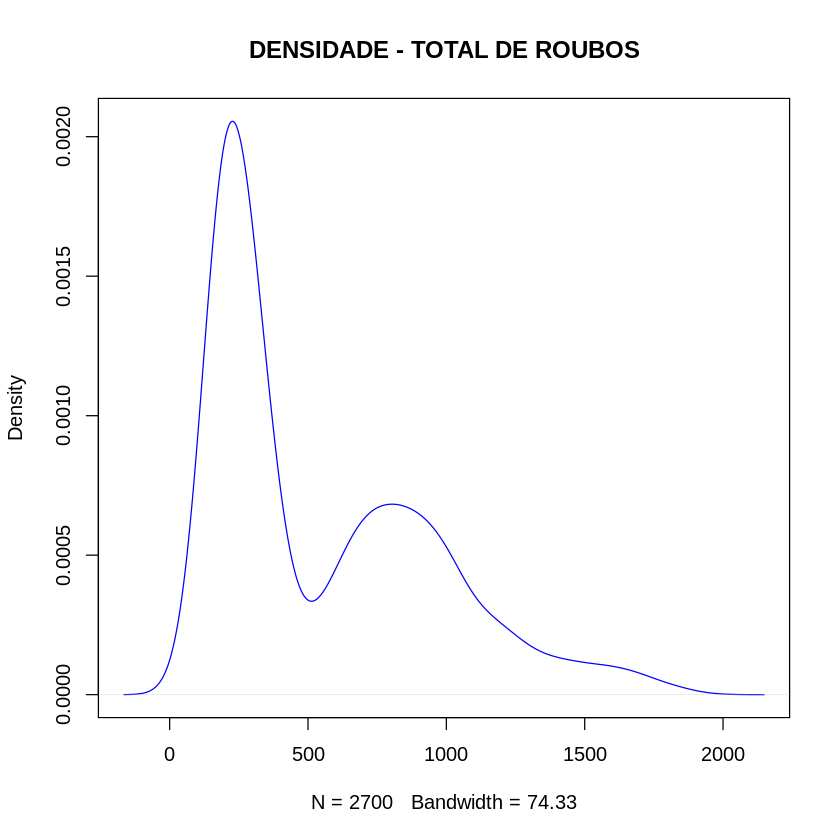

In [ ]:
# Plotando densidade dos dados
plot(density(df$TOTAL_CRIME), main = "DENSIDADE - TOTAL DE ROUBOS", col = "blue")

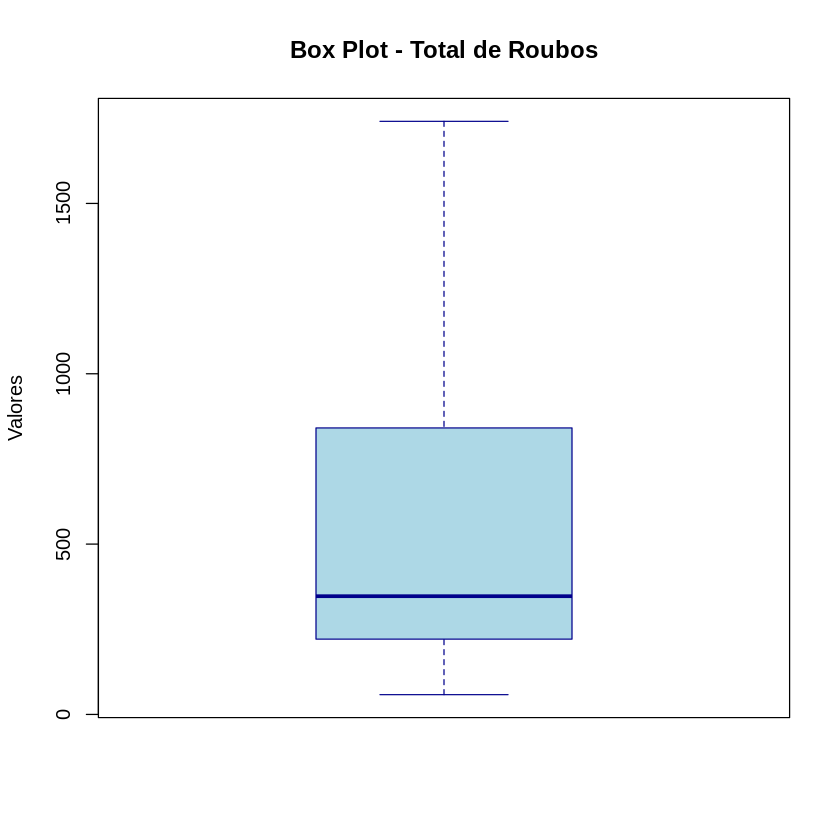

In [ ]:
# Plotando boxplot dos dados
boxplot(df$TOTAL_CRIME,
main = "Box Plot - Total de Roubos",
ylab = "Valores",
col = "lightblue",
border = "darkblue",
outline = FALSE,
notch = F)

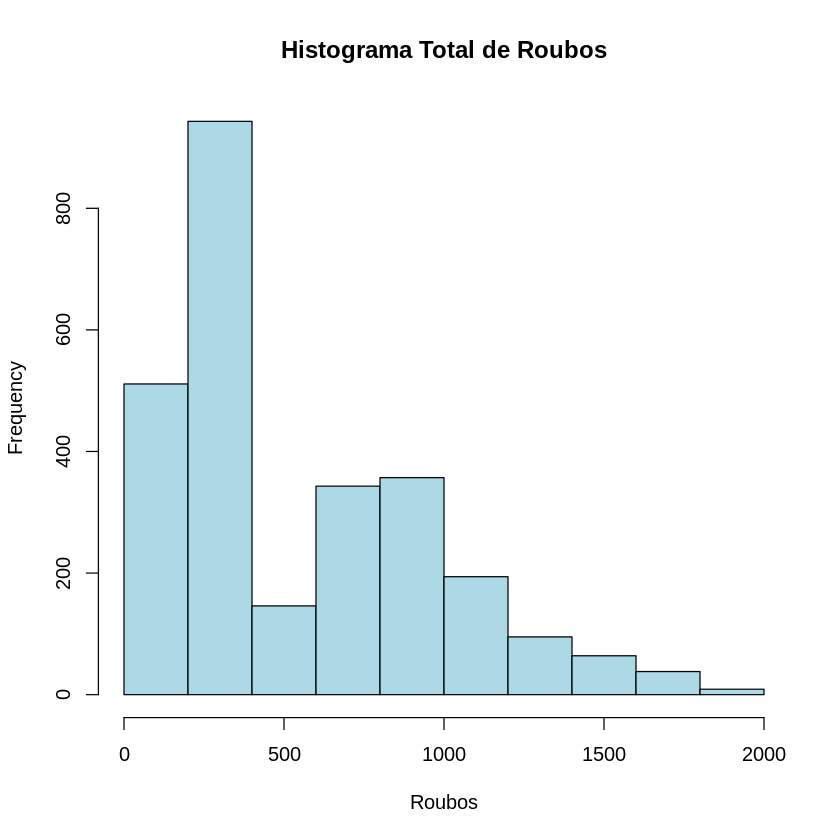

In [ ]:
# Plotando histograma dos dados
roubos <- df$TOTAL_CRIME

hist(roubos,
     col = "lightblue",
     main = "Histograma Total de Roubos",
     xlab = "Roubos")

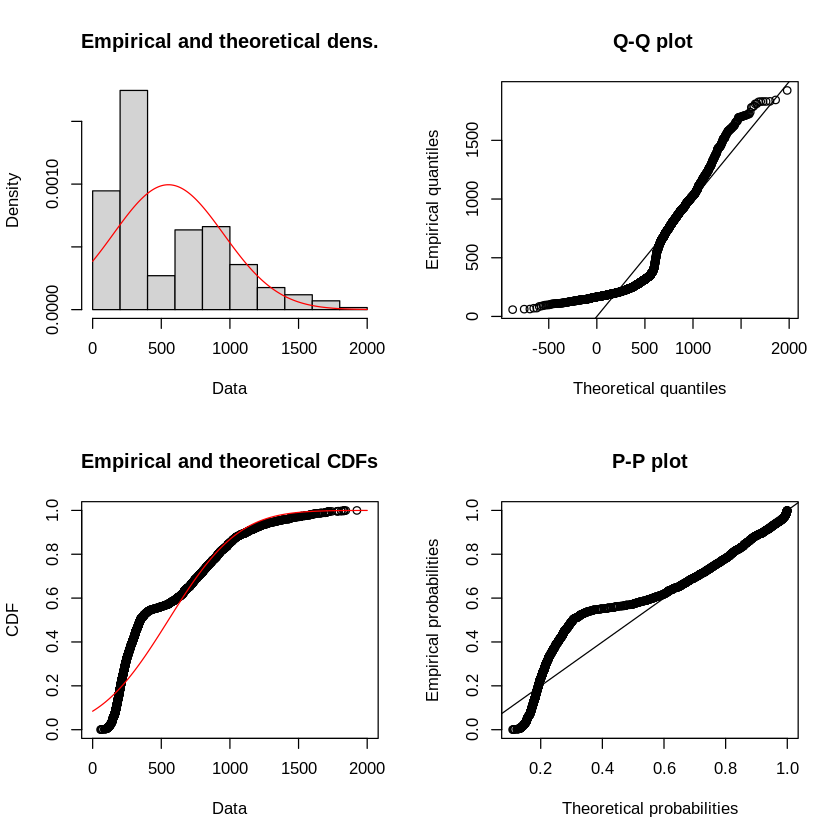

In [ ]:
# Ajustando distribuição normal e plotando o ajuste
ajuste <- fitdist(df$TOTAL_CRIME, "norm")
plot(ajuste)

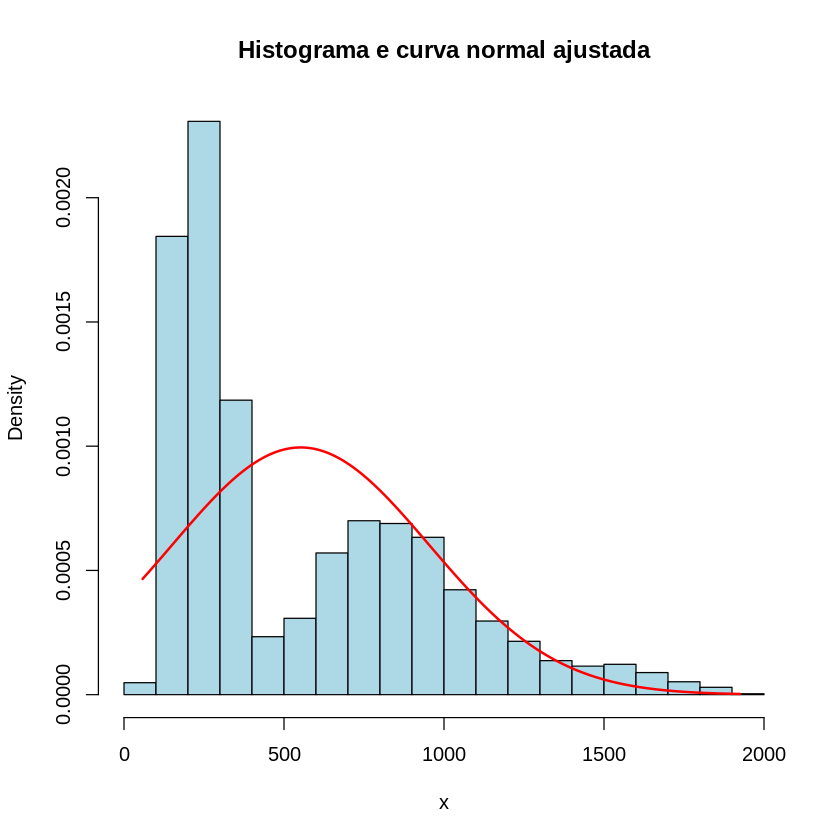

In [ ]:
# Ajustando normal e sobrepondo curva ao histograma
x <- df$TOTAL_CRIME

ajuste_norm <- fitdist(x, "norm")
hist(x, breaks = 20, probability = TRUE, col = "lightblue",
     main = "Histograma e curva normal ajustada", xlab = "x")

x_seq <- seq(min(x), max(x), length.out = 200)

lines(x_seq, dnorm(x_seq, mean = ajuste_norm$estimate["mean"],
                         sd   = ajuste_norm$estimate["sd"]),
      col = "red", lwd = 2)

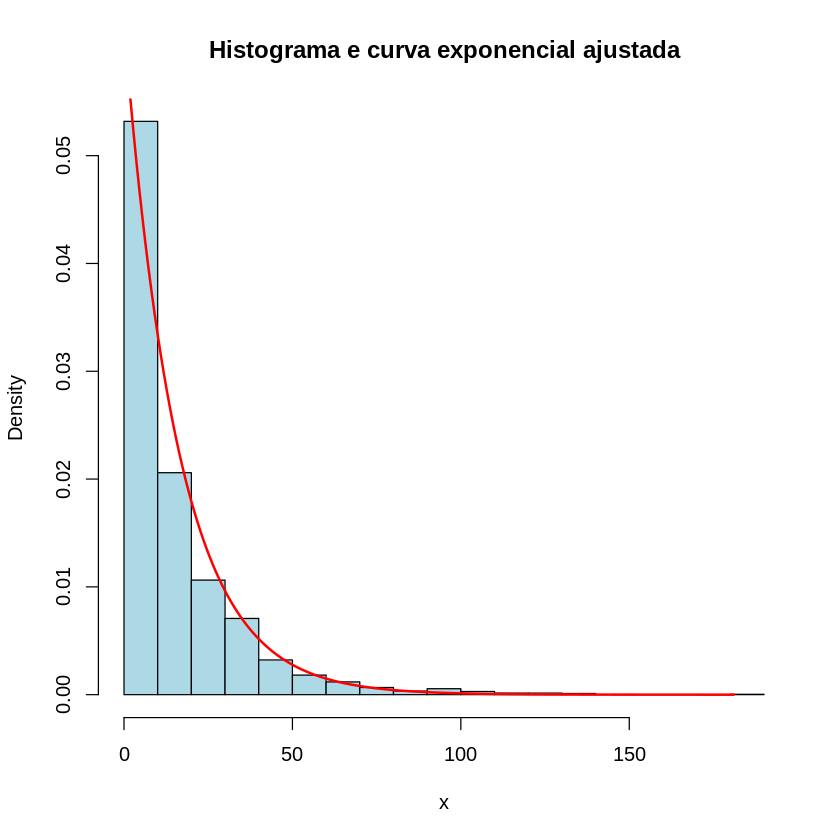

In [ ]:
x <- df$ROUBO_VEICULO
ajuste_exp <- fitdist(x, "exp")

hist(x, breaks = 20, probability = TRUE, col = "lightblue",
     main = "Histograma e curva exponencial ajustada", xlab = "x")

x_seq <- seq(min(x), max(x), length.out = 200)

lines(x_seq, dexp(x_seq, rate = ajuste_exp$estimate["rate"]),
      col = "red", lwd = 2)

In [ ]:
# Selecionando variáveis, calculando matriz de correlação
vars <- df %>%
  dplyr::select(
    FURTO_OUTROS,
    FURTO_VEICULO,
    HOMICIDIO_CULPOSO_ACIDENTE_TRANSITO,
    HOMICIDIO_CULPOSO_OUTROS,
    HOMICIDIO_DOLOSO,
    LATROCINIO,
    LESAO_CORPORAL_ACIDENTE_TRANSITO,
    LESAO_CORPORAL_CULPOSA_OUTRAS,
    LESAO_CORPORAL_DOLOSA,
    ROUBO_BANCO,
    ROUBO_CARGA,
    ROUBO_OUTROS,
    ROUBO_VEICULO,
    TENTATIVA_HOMICIDIO
  )
cor_mat <- cor(vars, use = "complete.obs")

# Transformando em data frame
cor_df <- as.data.frame(as.table(cor_mat))

# Removendo correlação = 1
cor_df <- cor_df[cor_df$Freq != 1, ]

# Removendos duplicados (A-B e B-A)
cor_df <- cor_df[as.character(cor_df$Var1) < as.character(cor_df$Var2), ]

# Ordenando correlação
cor_df <- cor_df[order(-cor_df$Freq), ]

cor_df

,Var1,Var2,Freq
,<fct>,<fct>,<dbl>
15,FURTO_OUTROS,FURTO_VEICULO,0.8567778
155,FURTO_OUTROS,ROUBO_OUTROS,0.8327128
119,LESAO_CORPORAL_ACIDENTE_TRANSITO,LESAO_CORPORAL_DOLOSA,0.8073829
113,FURTO_OUTROS,LESAO_CORPORAL_DOLOSA,0.7936468
161,LESAO_CORPORAL_ACIDENTE_TRANSITO,ROUBO_OUTROS,0.7801618
163,LESAO_CORPORAL_DOLOSA,ROUBO_OUTROS,0.7745117
114,FURTO_VEICULO,LESAO_CORPORAL_DOLOSA,0.7641183
156,FURTO_VEICULO,ROUBO_OUTROS,0.7566499
85,FURTO_OUTROS,LESAO_CORPORAL_ACIDENTE_TRANSITO,0.7295092


(Intercept)           y 
  45.928703    2.632692

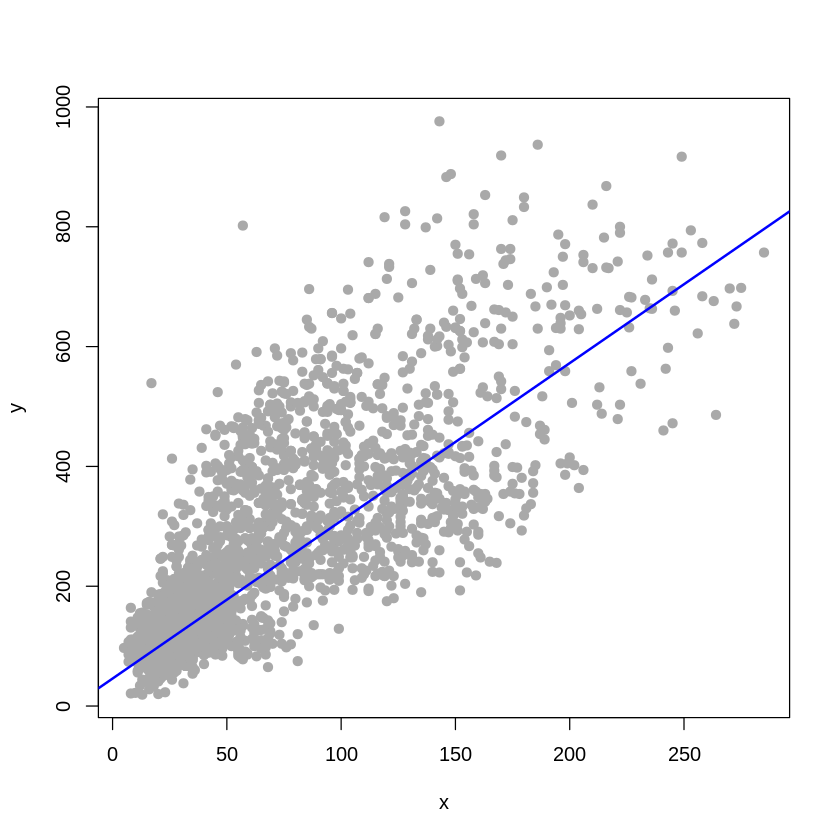

In [ ]:
# Definindo target e preditora
x <- df$FURTO_OUTROS
y <- df$LESAO_CORPORAL_DOLOSA

# Calculando o modelo linear
modelo = lm(
  formula = x ~ y,
  data = df,
  subset = x > 0,
  weights = 1/x,
  na.action = na.omit
)

# Mostrando os coeficientes
coef(modelo)

# Gerando o gráfico
plot(y, x , pch = 19, col = "darkgray", xlab = "x", ylab = "y")
abline(modelo, col = "blue", lwd = 2)

In [ ]:
df_lag <- df %>%
  arrange(df) %>%
  mutate(furto_lag1 = lag(FURTO_OUTROS, 1),
         furto_lag2 = lag(FURTO_OUTROS, 2))

cor(df_lag$furto_lag1, df$LESAO_CORPORAL_DOLOSA, use = "complete.obs")

[1] 0.02337946

In [ ]:
grangertest(LESAO_CORPORAL_DOLOSA ~ FURTO_OUTROS, order = 2, data = df)

,Res.Df,Df,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
1,2693,NA,NA,NA
2,2695,-2,28.96232,3.590795e-13


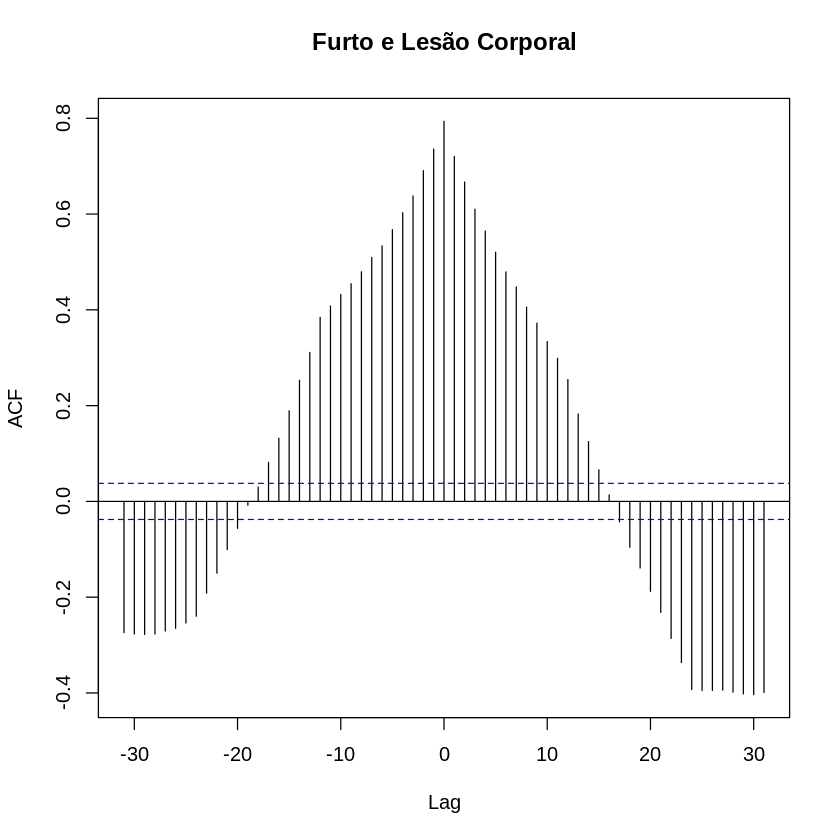

In [ ]:
ts_furto <- ts(df$FURTO_OUTROS)
ts_lesao <- ts(df$LESAO_CORPORAL_DOLOSA)

ccf(ts_furto, ts_lesao, main = "Furto e Lesão Corporal")

In [ ]:
library(dplyr)

df %>%
  group_by(MUNICIPIO) %>%
  summarise(correlacao = cor(FURTO_OUTROS, LESAO_CORPORAL_DOLOSA, use = "complete.obs"))

MUNICIPIO,correlacao
<chr>,<dbl>
Bertioga,0.3714668
Cubatão,0.3252761
Guarujá,0.2188670
Itanhaém,0.1439950
Mongaguá,0.2290224
Peruíbe,0.3431410
Praia Grande,0.3022170
Santos,0.6250391
São Vicente,0.2327470


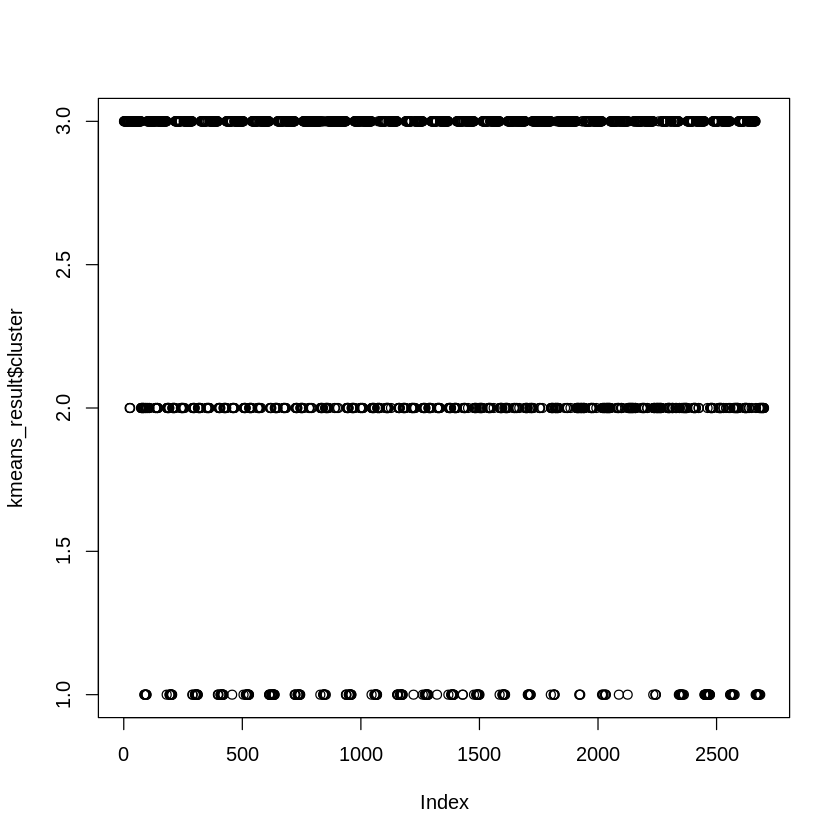

In [ ]:
dados <- df[, c("FURTO_OUTROS", "LESAO_CORPORAL_DOLOSA")]

kmeans_result <- kmeans(dados, centers = 3)

plot(kmeans_result$cluster)

In [31]:
# Treino e teste do modelo (80|20)

n <- nrow(df)
train_index <- sample(1:n, size = 0.8 * n)

train <- df[train_index, ]
test  <- df[-train_index, ]

knn_pred <- knn(
  train = train[, 5:7],
  test  = test[, 5:7],
  cl    = train[, 17],
  k     = 5
)

data.frame(knn_pred)

knn_pred
<fct>
36
33
16
206
301
307
44
217
37
